In [23]:
# Install required packages
!pip install torch torchvision torchaudio torch-geometric -q
!pip install tqdm scikit-learn matplotlib pandas numpy opencv-python networkx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.2/821.2 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 4.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 41.0 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 36.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 4.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 22.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 9.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 7.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [24]:
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.0.0+cu118.html
!pip install torch-geometric

Looking in links: https://data.pyg.org/whl/torch-2.0.0+cu118.html


In [25]:
!pip install numpy pandas scikit-learn matplotlib seaborn tqdm wfdb
!pip install torch-geometric torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.0.0+cu118.html

Looking in links: https://data.pyg.org/whl/torch-2.0.0+cu118.html


In [5]:
df = pd.read_csv('/kaggle/input/ptbxl-data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/ptbxl_database.csv')
df = df[['ecg_id', 'filename_hr', 'scp_codes']]
df['scp_codes'] = df['scp_codes'].apply(eval)

# Keep only ECGs that contain 'NORM' or 'IMI'
def get_label(codes):
    if 'NORM' in codes:
        return 'NORM'
    elif 'IMI' in codes:
        return 'IMI'
    else:
        return None

df['label'] = df['scp_codes'].apply(get_label)
df = df[df['label'].notnull()]
df['y'] = df['label'].map({'NORM': 0, 'IMI': 1})
df = df.reset_index(drop=True)

print("Filtered samples:", len(df))


Filtered samples: 12212


In [9]:
import torch
from torch_geometric.data import Data
import networkx as nx
import os

output_dir = './signal_graphs'
os.makedirs(output_dir, exist_ok=True)

def signal_to_graph(signal, label):
    """
    Converts 1D ECG signal into a graph with 8-connectivity.
    """
    edge_index = []
    num_nodes = len(signal)

    for i in range(num_nodes):
        if i > 0:
            edge_index.append([i, i - 1])
        if i < num_nodes - 1:
            edge_index.append([i, i + 1])
        if i > 2:
            edge_index.append([i, i - 3])
        if i < num_nodes - 3:
            edge_index.append([i, i + 3])
    
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    x = torch.tensor(signal, dtype=torch.float).view(-1, 1)
    y = torch.tensor([label], dtype=torch.long)
    return Data(x=x, edge_index=edge_index, y=y)

# Save graphs
graph_list = []
for i, row in tqdm(df.iterrows(), total=len(df)):
    rec_path = '/kaggle/input/ptbxl-data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/' + row['filename_hr']
    record = wfdb.rdrecord(rec_path)
    signal = record.p_signal[:, 0]  # Use lead I (0)
    
    graph = signal_to_graph(signal, row['y'])
    torch.save(graph, f'{output_dir}/{i}.pt')


100%|██████████| 12212/12212 [09:16<00:00, 21.94it/s]


In [10]:
from sklearn.model_selection import train_test_split
import shutil

train_dir = './graph_split/train'
val_dir = './graph_split/val'
test_dir = './graph_split/test'
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

all_graphs = sorted(os.listdir(output_dir))
train_val, test = train_test_split(all_graphs, test_size=0.1, random_state=42)
train, val = train_test_split(train_val, test_size=0.1111, random_state=42)  # ~0.1 total val

for g in train:
    shutil.copy(f'{output_dir}/{g}', f'{train_dir}/{g}')
for g in val:
    shutil.copy(f'{output_dir}/{g}', f'{val_dir}/{g}')
for g in test:
    shutil.copy(f'{output_dir}/{g}', f'{test_dir}/{g}')

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")


Train: 9769, Val: 1221, Test: 1222


/tmp/ipykernel_31/1710625853.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph = torch.load(os.path.join(graph_folder, graph_file))


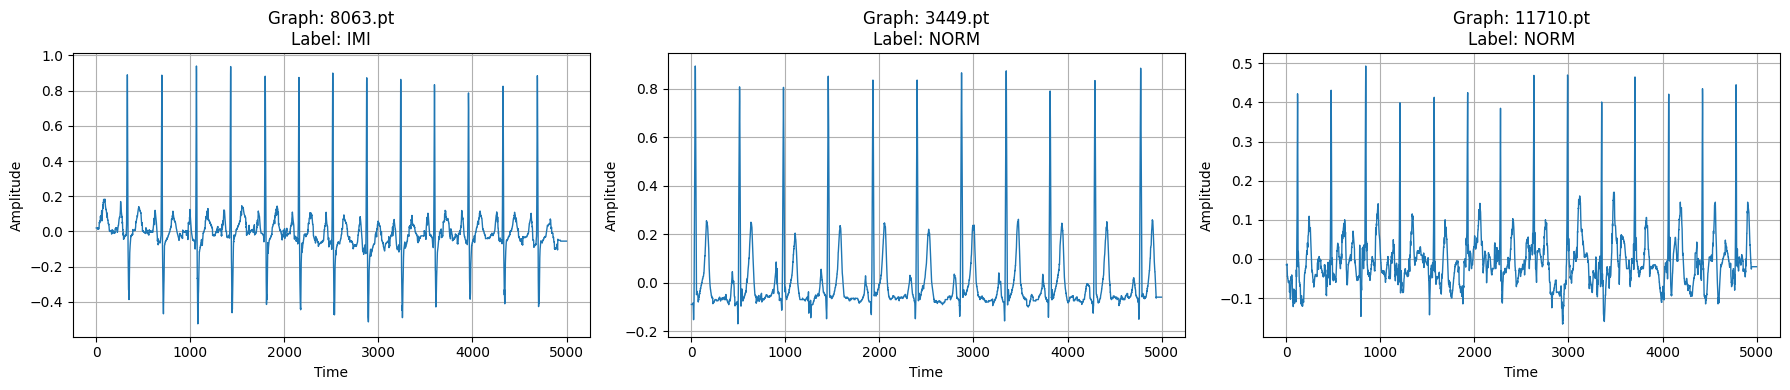

In [13]:
import torch
import matplotlib.pyplot as plt
import random
from torch_geometric.data import Data
import os

# Label map
label_map = {0: 'NORM', 1: 'IMI'}

# Get 3 random graph filenames
graph_folder = './signal_graphs'
graph_files = random.sample(os.listdir(graph_folder), 3)

# Plotting
plt.figure(figsize=(18, 4))
for i, graph_file in enumerate(graph_files):
    graph = torch.load(os.path.join(graph_folder, graph_file))
    signal = graph.x.squeeze().numpy()
    label = label_map[int(graph.y.item())]

    plt.subplot(1, 3, i+1)
    plt.plot(signal, linewidth=1)
    plt.title(f"Graph: {graph_file}\nLabel: {label}")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.grid(True)

plt.tight_layout()
plt.show()


/tmp/ipykernel_31/2932083504.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(os.path.join(graph_folder, graph_file))


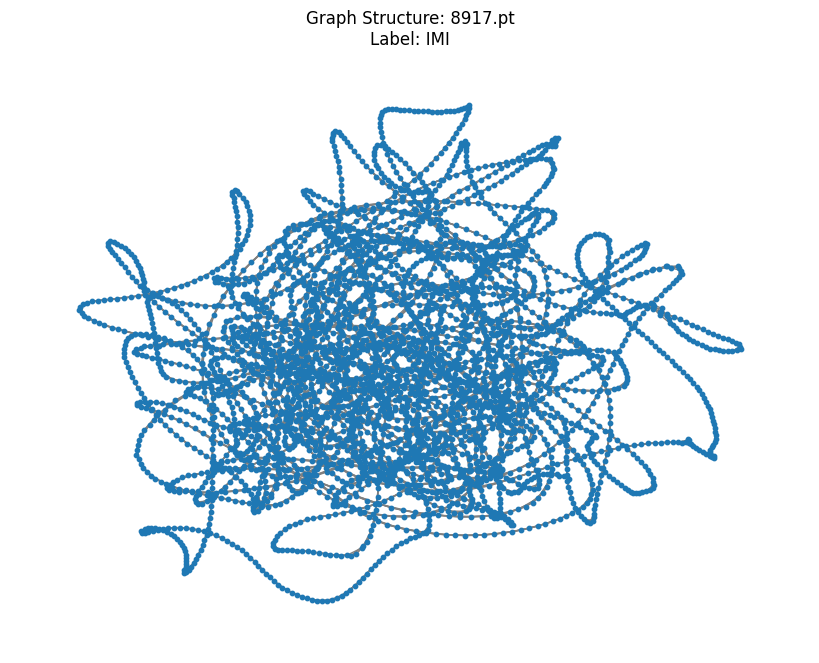

In [14]:
import torch
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx
import random
import os

# Load a random graph file
graph_folder = './signal_graphs'
graph_file = random.choice(os.listdir(graph_folder))
data = torch.load(os.path.join(graph_folder, graph_file))

# Convert to NetworkX for visualization
G = to_networkx(data, to_undirected=True)

# Plot graph structure
plt.figure(figsize=(8, 6))
nx.draw(G, node_size=10, edge_color='gray')
plt.title(f"Graph Structure: {graph_file}\nLabel: {'NORM' if data.y.item()==0 else 'IMI'}")
plt.show()


/tmp/ipykernel_31/566166407.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graphs = [torch.load(os.path.join(folder, f)) for f in os.listdir(folder)]
/usr/local/lib/py

[Epoch 1] Train Acc: 0.7282 | Val Acc: 0.7912


Epoch 2: 100%|██████████| 153/153 [00:09<00:00, 15.55it/s]


[Epoch 2] Train Acc: 0.7785 | Val Acc: 0.7912


Epoch 3: 100%|██████████| 153/153 [00:09<00:00, 15.68it/s]


...

[Epoch 18] Train Acc: 0.7883 | Val Acc: 0.7993


Epoch 19: 100%|██████████| 153/153 [00:09<00:00, 15.59it/s]


[Epoch 19] Train Acc: 0.7889 | Val Acc: 0.7993


Epoch 20: 100%|██████████| 153/153 [00:09<00:00, 15.59it/s]


[Epoch 20] Train Acc: 0.7903 | Val Acc: 0.7952


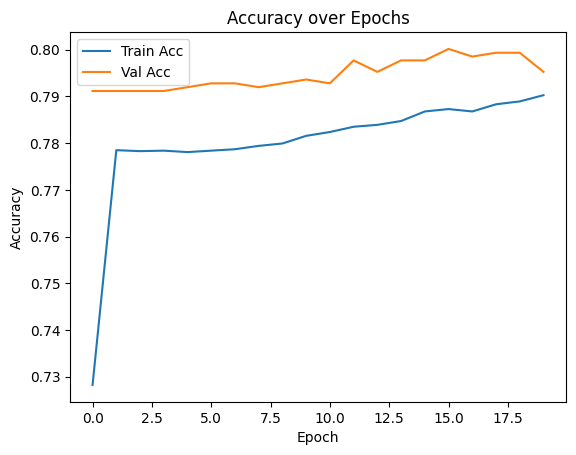


Classification Report:
              precision    recall  f1-score   support

        NORM       0.81      0.99      0.89       957
         IMI       0.79      0.14      0.24       265

    accuracy                           0.81      1222
   macro avg       0.80      0.56      0.56      1222
weighted avg       0.80      0.81      0.75      1222



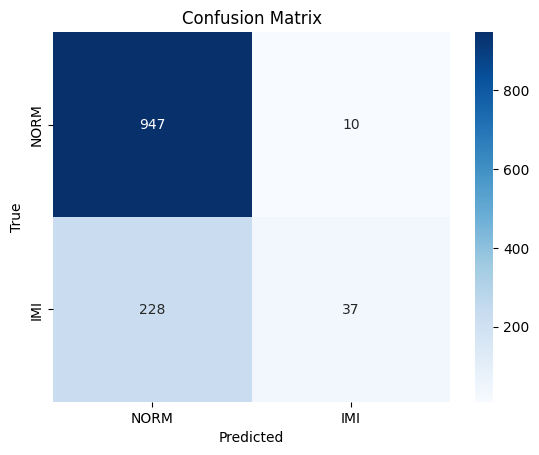

Test Accuracy: 0.8052373158756138


In [16]:
import os
import torch
import torch.nn.functional as F
from torch_geometric.data import DataLoader
from torch_geometric.nn import GCNConv, GraphSAGE, GATConv, global_mean_pool, GINConv
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# === Choose device ===
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# === Model choices ===
class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.lin = torch.nn.Linear(hidden_dim, num_classes)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x)

class GIN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        nn1 = torch.nn.Sequential(torch.nn.Linear(input_dim, hidden_dim), torch.nn.ReLU(),
                                  torch.nn.Linear(hidden_dim, hidden_dim))
        self.conv1 = GINConv(nn1)
        self.lin = torch.nn.Linear(hidden_dim, num_classes)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x)

# === Load data ===
def load_data(folder):
    graphs = [torch.load(os.path.join(folder, f)) for f in os.listdir(folder)]
    return graphs

train_graphs = load_data('./graph_split/train')
val_graphs   = load_data('./graph_split/val')
test_graphs  = load_data('./graph_split/test')

# === Dataloaders ===
train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=64)
test_loader  = DataLoader(test_graphs, batch_size=64)

# === Model ===
model = GCN(input_dim=train_graphs[0].num_node_features, hidden_dim=64, num_classes=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

# === Train Loop ===
train_accs, val_accs = [], []
for epoch in range(1, 21):
    model.train()
    total_loss, correct = 0, 0

    for data in tqdm(train_loader, desc=f"Epoch {epoch}"):
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pred = out.argmax(dim=1)
        correct += int((pred == data.y).sum())

    train_acc = correct / len(train_graphs)
    train_accs.append(train_acc)

    # === Validation ===
    model.eval()
    correct = 0
    with torch.no_grad():
        for data in val_loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)
            pred = out.argmax(dim=1)
            correct += int((pred == data.y).sum())
    val_acc = correct / len(val_graphs)
    val_accs.append(val_acc)

    print(f"[Epoch {epoch}] Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

# === Plot accuracy ===
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()
plt.show()

# === Final Evaluation ===
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        pred = out.argmax(dim=1)
        all_preds += pred.cpu().tolist()
        all_labels += data.y.cpu().tolist()

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['NORM', 'IMI']))

# === Confusion Matrix ===
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NORM','IMI'], yticklabels=['NORM','IMI'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print("Test Accuracy:", accuracy_score(all_labels, all_preds))


In [4]:
# Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
import networkx as nx
import pickle
from sklearn.model_selection import train_test_split


In [4]:
!pip install wfdb tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 12.3 MB/s eta 0:00:00


In [2]:
import pandas as pd

# Load the CSV
df = pd.read_csv('/kaggle/input/ptbxl-data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/ptbxl_database.csv')

# Convert 'scp_codes' from string to dictionary
import ast
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)

# Extract the first label
df['first_label'] = df['scp_codes'].apply(lambda x: list(x.keys())[0] if len(x) > 0 else None)

# Filter for NORM and IMI
df_filtered = df[df['first_label'].isin(['NORM', 'IMI'])]

# Determine the maximum allowed sample size (minimum of the two)
sample_size = min(
    df_filtered[df_filtered['first_label'] == 'NORM'].shape[0],
    df_filtered[df_filtered['first_label'] == 'IMI'].shape[0]
)

print(f"Sampling {sample_size} signals from each class...")

# Sample balanced data
df_norm = df_filtered[df_filtered['first_label'] == 'NORM'].sample(n=sample_size, random_state=42)
df_imi  = df_filtered[df_filtered['first_label'] == 'IMI'].sample(n=sample_size, random_state=42)

# Combine and shuffle
df_binary = pd.concat([df_norm, df_imi]).sample(frac=1, random_state=42).reset_index(drop=True)

# Save the balanced dataset
df_binary.to_csv('filtered_norm_imi_balanced.csv', index=False)

print(f"✅ Saved 'filtered_norm_imi_balanced.csv' with {len(df_binary)} signals.")


Sampling 2329 signals from each class...
✅ Saved 'filtered_norm_imi_balanced.csv' with 4658 signals.


In [7]:
import os
import pandas as pd
import wfdb
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Output directory
output_dir = "images_norm_imi"
os.makedirs(output_dir, exist_ok=True)


In [8]:
# Load filtered dataframe
df = pd.read_csv("filtered_norm_imi_balanced.csv")

# Base path to .dat and .hea files
base_path = "/kaggle/input/ptbxl-data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/"

# Generate images
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Converting signals to images"):
    rec_path = os.path.join(base_path, row['filename_hr'])

    try:
        # Load signal
        record = wfdb.rdrecord(rec_path)

        # Use the first lead (channel 0)
        signal = record.p_signal[:, 0]

        # Plot the signal
        fig, ax = plt.subplots(figsize=(6, 2))
        ax.plot(signal, color='black', linewidth=0.5)
        ax.axis('off')  # remove axes

        # Save image
        image_filename = f"{row['filename_hr'].replace('/', '_')}.png"
        image_path = os.path.join(output_dir, image_filename)
        fig.savefig(image_path, bbox_inches='tight', pad_inches=0)
        plt.close(fig)

    except Exception as e:
        print(f"Failed to process {rec_path}: {e}")


Converting signals to images:   0%|          | 0/4658 [00:00<?, ?it/s]

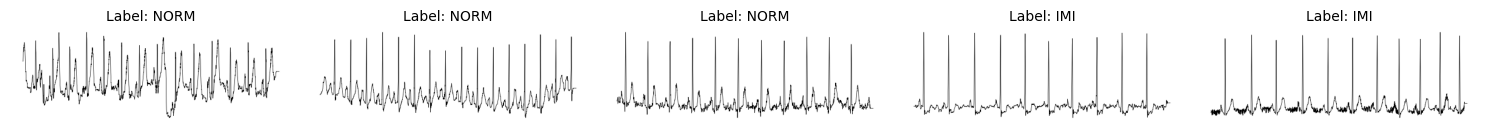

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image

# Load CSV
df = pd.read_csv("filtered_norm_imi_balanced.csv")

# Sample 5 random rows
samples = df.sample(n=5, random_state=42)

# Image folder path
image_folder = "/kaggle/working/images_norm_imi"

# Plot images
plt.figure(figsize=(15, 5))
for i, (_, row) in enumerate(samples.iterrows()):
    # Convert filename_hr to correct filename
    raw_name = row['filename_hr']  # e.g., records500/13000/13355_hr
    corrected_name = raw_name.replace('/', '_') + '.png'  # e.g., records500_13000_13355_hr.png
    image_path = os.path.join(image_folder, corrected_name)

    # Check if file exists
    if not os.path.exists(image_path):
        print(f"Image not found: {corrected_name}")
        continue

    # Plot
    image = Image.open(image_path)
    plt.subplot(1, 5, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Label: {row['first_label']}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [10]:
!pip install opencv-python-headless


In [11]:
import cv2
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# Paths
image_folder = "/kaggle/working/images_norm_imi"          # Original images folder
edge_folder = "edges_norm_imi"            # Folder to save edge images

os.makedirs(edge_folder, exist_ok=True)

# Load filtered dataset CSV
df = pd.read_csv("filtered_norm_imi_balanced.csv")

# Function to convert filename_hr to image filename
def get_image_filename(filename_hr):
    return filename_hr.replace('/', '_') + '.png'

# Loop over all images and apply edge detection
for idx, row in df.iterrows():
    img_name = get_image_filename(row['filename_hr'])
    img_path = os.path.join(image_folder, img_name)
    edge_path = os.path.join(edge_folder, img_name)
    
    # Check if image exists
    if not os.path.exists(img_path):
        print(f"Image not found: {img_name}")
        continue
    
    # Read image in grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    # Apply Canny edge detection
    edges = cv2.Canny(img, threshold1=50, threshold2=150)
    
    # Save edge detected image
    cv2.imwrite(edge_path, edges)

print(f"Edge detection complete. Saved images to '{edge_folder}'")


Edge detection complete. Saved images to 'edges_norm_imi'


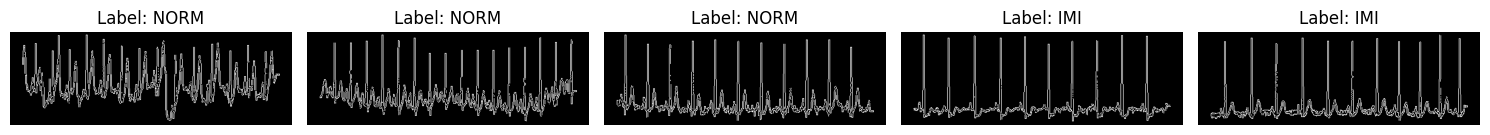

In [11]:
# Sample 5 random rows from dataframe
samples = df.sample(n=5, random_state=42)

plt.figure(figsize=(15,5))
for i, (_, row) in enumerate(samples.iterrows()):
    edge_img_name = get_image_filename(row['filename_hr'])
    edge_img_path = os.path.join(edge_folder, edge_img_name)
    
    if not os.path.exists(edge_img_path):
        print(f"Edge image not found: {edge_img_name}")
        continue
    
    edge_img = Image.open(edge_img_path)
    plt.subplot(1, 5, i+1)
    plt.imshow(edge_img, cmap='gray')
    plt.title(f"Label: {row['first_label']}")
    plt.axis('off')

plt.tight_layout()
plt.show()


Total images to process: 4658
✅ Edge detection completed and images saved.


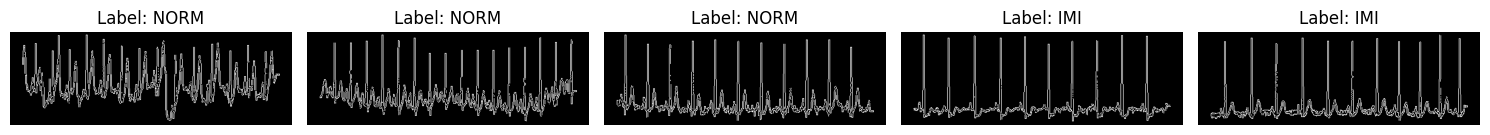

In [12]:
import os
import cv2
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# Define folders
image_folder = "/kaggle/working/images_norm_imi"      # Your original images folder
edge_folder = "/kaggle/working/edges_norm_imi"        # Where edge detected images will be saved
os.makedirs(edge_folder, exist_ok=True)

# Load balanced CSV with filenames and labels
df = pd.read_csv("filtered_norm_imi_balanced.csv")

# Helper function: Convert 'records500/00000/00001_hr' -> 'records500_00000_00001_hr.png'
def convert_filename(filename_hr):
    return filename_hr.replace('/', '_') + '.png'

print(f"Total images to process: {len(df)}")

# Edge Detection loop
for idx, row in df.iterrows():
    img_name = convert_filename(row['filename_hr'])
    img_path = os.path.join(image_folder, img_name)
    edge_path = os.path.join(edge_folder, img_name)

    if not os.path.exists(img_path):
        print(f"Image not found: {img_path}")
        continue
    
    # Read image in grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    # Apply Canny edge detection
    edges = cv2.Canny(img, 50, 150)

    # Save edge detected image
    cv2.imwrite(edge_path, edges)

print("✅ Edge detection completed and images saved.")

# Visualize 5 random edge detected images with labels
samples = df.sample(n=5, random_state=42)

plt.figure(figsize=(15,5))
for i, (_, row) in enumerate(samples.iterrows()):
    edge_img_name = convert_filename(row['filename_hr'])
    edge_img_path = os.path.join(edge_folder, edge_img_name)

    if not os.path.exists(edge_img_path):
        print(f"Edge image not found: {edge_img_path}")
        continue

    edge_img = Image.open(edge_img_path)
    plt.subplot(1, 5, i+1)
    plt.imshow(edge_img, cmap='gray')
    plt.title(f"Label: {row['first_label']}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [23]:
import os
import networkx as nx
import numpy as np
import pandas as pd
import pickle
from PIL import Image
from tqdm import tqdm

# Paths
edge_folder = "/kaggle/working/edges_norm_imi"
graph_folder = "/kaggle/working/graphs_norm_imi"
os.makedirs(graph_folder, exist_ok=True)

# Load the filtered CSV
df = pd.read_csv("filtered_norm_imi_balanced.csv")

# Convert filename helper
def convert_filename(filename_hr):
    return filename_hr.replace('/', '_') + '.png'

# Convert image to graph
def image_to_graph(img_path):
    img = Image.open(img_path).convert('L')  # Grayscale
    img_array = np.array(img)
    bin_img = (img_array > 0).astype(np.uint8)

    G = nx.Graph()
    rows, cols = bin_img.shape

    for r in range(rows):
        for c in range(cols):
            if bin_img[r, c] == 1:
                node_id = r * cols + c
                G.add_node(node_id, intensity=int(img_array[r, c]))

                neighbors = []
                if r > 0 and bin_img[r-1, c] == 1:
                    neighbors.append(((r-1)*cols + c))
                if r < rows-1 and bin_img[r+1, c] == 1:
                    neighbors.append(((r+1)*cols + c))
                if c > 0 and bin_img[r, c-1] == 1:
                    neighbors.append((r*cols + (c-1)))
                if c < cols-1 and bin_img[r, c+1] == 1:
                    neighbors.append((r*cols + (c+1)))

                for nb in neighbors:
                    G.add_edge(node_id, nb)

    return G

# --- Batch-wise processing ---
batch_size = 500
num_samples = len(df)
num_batches = (num_samples + batch_size - 1) // batch_size

print(f"⚙️ Constructing {num_samples} graphs in {num_batches} batches of {batch_size} each...")

for batch_num in range(num_batches):
    start_idx = batch_num * batch_size
    end_idx = min((batch_num + 1) * batch_size, num_samples)
    batch_df = df.iloc[start_idx:end_idx]

    print(f"\n📦 Processing batch {batch_num + 1}/{num_batches} — Samples {start_idx} to {end_idx - 1}")
    for _, row in tqdm(batch_df.iterrows(), total=len(batch_df)):
        img_name = convert_filename(row['filename_hr'])
        img_path = os.path.join(edge_folder, img_name)
        graph_path = os.path.join(graph_folder, img_name.replace('.png', '.pkl'))

        if not os.path.exists(img_path):
            print(f"❌ Missing: {img_path}")
            continue

        try:
            G = image_to_graph(img_path)
            graph_data = {
                'graph': G,
                'label': row['first_label'],
                'filename': row['filename_hr']
            }
            with open(graph_path, 'wb') as f:
                pickle.dump(graph_data, f)
        except Exception as e:
            print(f"⚠️ Error processing {img_path}: {e}")

print("\n✅ All batches processed. Graphs saved in:", graph_folder)


⚙️ Constructing 4658 graphs in 10 batches of 500 each...

📦 Processing batch 1/10 — Samples 0 to 499


100%|██████████| 500/500 [01:30<00:00,  5.52it/s]



📦 Processing batch 2/10 — Samples 500 to 999


100%|██████████| 500/500 [01:30<00:00,  5.53it/s]



📦 Processing batch 3/10 — Samples 1000 to 1499


...


📦 Processing batch 9/10 — Samples 4000 to 4499


100%|██████████| 500/500 [01:30<00:00,  5.55it/s]



📦 Processing batch 10/10 — Samples 4500 to 4657


100%|██████████| 158/158 [00:28<00:00,  5.48it/s]


✅ All batches processed. Graphs saved in: /kaggle/working/graphs_norm_imi


In [5]:
import numpy as np
import networkx as nx
import pickle
import pandas as pd
import wfdb
from tqdm import tqdm
import os

# Config
output_folder = "/kaggle/working/graphs_from_signal"
os.makedirs(output_folder, exist_ok=True)

df = pd.read_csv("filtered_norm_imi_balanced.csv")
signal_folder = "/kaggle/input/ptbxl-data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/"

# Label mapping (binary classification)
label_map = {"NORM": 0, "IMI": 1}

# Optional: Normalize and pad/crop signal to fixed length
def preprocess_signal(signal, target_len=5000):
    signal = (signal - np.mean(signal)) / np.std(signal)  # z-score normalization
    if len(signal) > target_len:
        signal = signal[:target_len]
    elif len(signal) < target_len:
        signal = np.pad(signal, (0, target_len - len(signal)), mode='constant')
    return signal

# Load ECG signal from .dat/.hea
def load_signal(filename_hr):
    record_path = os.path.join(signal_folder, filename_hr)
    record = wfdb.rdrecord(record_path)
    signal = record.p_signal[:, 0]  # Lead I (column 0)
    return signal

# Create 1D line graph from ECG signal
def signal_to_graph(signal):
    G = nx.Graph()
    for i in range(len(signal)):
        G.add_node(i, signal=float(signal[i]))
        if i > 0:
            G.add_edge(i - 1, i)
    return G

print(f"📈 Building signal-based graphs for {len(df)} samples...")

for idx, row in tqdm(df.iterrows(), total=len(df)):
    try:
        signal = load_signal(row['filename_hr'])
        signal = preprocess_signal(signal, target_len=5000)  # Normalize and fix length
        G = signal_to_graph(signal)

        graph_data = {
            'graph': G,
            'label': row['first_label'],
            'signal': signal.tolist(),  # Save signal separately for PyG conversion
            'filename': row['filename_hr']
        }

        graph_path = os.path.join(output_folder, row['filename_hr'].replace("/", "_") + ".pkl")
        with open(graph_path, 'wb') as f:
            pickle.dump(graph_data, f)
    
    except Exception as e:
        print(f"❌ Error processing {row['filename_hr']}: {e}")

print(f"✅ Done! Graphs saved to '{output_folder}' folder.")


📈 Building signal-based graphs for 4658 samples...


100%|██████████| 4658/4658 [02:31<00:00, 30.73it/s]

✅ Done! Graphs saved to '/kaggle/working/graphs_from_signal' folder.


In [ ]:
import os
import random
import torch
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.utils import to_networkx

# Path to one of your graph folders (e.g., train)
graph_folder = '/kaggle/working/graphs_from_split'

# List all .pkl files
graph_files = [f for f in os.listdir(graph_folder) if f.endswith('.pkl')]

# Select 3 random graphs
random_graphs = random.sample(graph_files, 3)

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, file in enumerate(random_graphs):
    # Load the graph
    data_path = os.path.join(graph_folder, file)
    data = torch.load(data_path)

    # Convert PyG Data to NetworkX graph
    G = to_networkx(data, to_undirected=True)

    # Get label
    label = int(data.y.item())

    # Plot
    ax = axes[i]
    ax.set_title(f'Graph {i+1}\nLabel: {label}', fontsize=12)
    nx.draw(G, ax=ax, node_size=20, node_color='skyblue', edge_color='gray', with_labels=False)

plt.suptitle("Random ECG Graphs with Labels", fontsize=16)
plt.tight_layout()
plt.show()


In [80]:
import pickle

file_path = "/kaggle/working/signal_graph_split_fixed/train/records500_00000_00001_hr.pkl"

with open(file_path, "rb") as f:
    obj = pickle.load(f)

print(type(obj))
print(obj)  # or print dir(obj) if it's a complex object


<class 'torch_geometric.data.data.Data'>
Data(edge_index=[2, 9998], value=[5000], num_nodes=5000, x=[5000, 1], y=[1])


In [8]:
import os
import pickle
import torch
from torch_geometric.data import Data
from tqdm import tqdm

input_folder = "/kaggle/working/graphs_from_signal"
output_folder = "/kaggle/working/pyg_graphs_fast"
os.makedirs(output_folder, exist_ok=True)

label_map = {"NORM": 0, "IMI": 1}

# Precompute edge_index for chain graph of length 5000
num_nodes = 5000
edge_index = torch.tensor(
    [[i for i in range(num_nodes - 1)] + [i + 1 for i in range(num_nodes - 1)],
     [i + 1 for i in range(num_nodes - 1)] + [i for i in range(num_nodes - 1)]],
    dtype=torch.long
)

files = sorted([f for f in os.listdir(input_folder) if f.endswith(".pkl")])
print(f"Converting {len(files)} graphs to PyG Data format (fast)...")

for file in tqdm(files, desc="Converting graphs"):
    with open(os.path.join(input_folder, file), "rb") as f:
        obj = pickle.load(f)
    
    signal = obj["signal"]  # length 5000
    label = obj["label"]
    
    x = torch.tensor(signal, dtype=torch.float32).unsqueeze(1)  # node features
    
    y = torch.tensor([label_map[label]], dtype=torch.long)     # label
    
    data = Data(x=x, edge_index=edge_index, y=y)
    
    # Save PyG Data
    out_path = os.path.join(output_folder, file)
    with open(out_path, "wb") as f_out:
        pickle.dump(data, f_out)

print("✅ Fast conversion done. PyG graphs saved to:", output_folder)


Converting 4658 graphs to PyG Data format (fast)...


Converting graphs: 100%|██████████| 4658/4658 [00:53<00:00, 86.72it/s] 

✅ Fast conversion done. PyG graphs saved to: /kaggle/working/pyg_graphs_fast


In [9]:
import os
import shutil
from sklearn.model_selection import train_test_split

input_folder = "/kaggle/working/pyg_graphs_fast"
output_root = "/kaggle/working/pyg_graphs_fast_split"

os.makedirs(output_root, exist_ok=True)
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(output_root, split), exist_ok=True)

all_files = sorted([f for f in os.listdir(input_folder) if f.endswith('.pkl')])

# First split train+val and test (90%,10%)
train_val_files, test_files = train_test_split(all_files, test_size=0.1, random_state=42, shuffle=True)

# Then split train and val (from 90%, split 80% train, 10% val)
train_files, val_files = train_test_split(train_val_files, test_size=1/9, random_state=42, shuffle=True)
# 1/9 ≈ 0.111 so val is approx 10% of total, train approx 80%

print(f"Train: {len(train_files)} val: {len(val_files)} test: {len(test_files)}")

for f in train_files:
    shutil.copy(os.path.join(input_folder, f), os.path.join(output_root, 'train', f))
for f in val_files:
    shutil.copy(os.path.join(input_folder, f), os.path.join(output_root, 'val', f))
for f in test_files:
    shutil.copy(os.path.join(input_folder, f), os.path.join(output_root, 'test', f))


Train: 3726 val: 466 test: 466


In [13]:
import shutil

source_folder = "/kaggle/working/pyg_graphs_fast_split"
output_zip = "/kaggle/working/pyg_graphs_fast_split.zip"

# Create the zip file
shutil.make_archive(output_zip.replace(".zip", ""), 'zip', source_folder)

print(f"Folder zipped successfully as: {output_zip}")


Folder zipped successfully as: /kaggle/working/pyg_graphs_fast_split.zip


In [67]:
import os
import pickle
from tqdm import tqdm
import torch
import torch.nn.functional as F
from torch_geometric.data import DataLoader, Dataset
from torch_geometric.nn import GINConv, global_add_pool
from sklearn.metrics import classification_report, accuracy_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Custom dataset class to load PyG Data objects from a folder
class PyGDataset(Dataset):
    def __init__(self, root_dir):
        super().__init__()
        self.root_dir = root_dir
        self.files = sorted([f for f in os.listdir(root_dir) if f.endswith('.pkl')])

    def len(self):
        return len(self.files)

    def get(self, idx):
        path = os.path.join(self.root_dir, self.files[idx])
        with open(path, 'rb') as f:
            data = pickle.load(f)
        return data.to(device)

# Define simple GIN model
class GIN(torch.nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, output_dim=2):
        super().__init__()
        nn1 = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, hidden_dim)
        )
        self.conv1 = GINConv(nn1)
        nn2 = torch.nn.Sequential(
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, hidden_dim)
        )
        self.conv2 = GINConv(nn2)
        self.lin = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = global_add_pool(x, batch)
        x = self.lin(x)
        return x

# Paths for splits
train_path = "/kaggle/working/pyg_graphs_fast_split/train"
val_path = "/kaggle/working/pyg_graphs_fast_split/val"
test_path = "/kaggle/working/pyg_graphs_fast_split/test"

# Load datasets
train_dataset = PyGDataset(train_path)
val_dataset = PyGDataset(val_path)
test_dataset = PyGDataset(test_path)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# Initialize model, optimizer, criterion
model = GIN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

def train_epoch():
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc="Training"):
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(train_dataset)

@torch.no_grad()
def evaluate(loader):
    model.eval()
    ys, preds = [], []
    for batch in loader:
        out = model(batch.x, batch.edge_index, batch.batch)
        pred = out.argmax(dim=1)
        ys.append(batch.y.cpu())
        preds.append(pred.cpu())
    ys = torch.cat(ys).numpy()
    preds = torch.cat(preds).numpy()
    acc = accuracy_score(ys, preds)
    report = classification_report(ys, preds, target_names=['NORM','IMI'])
    return acc, report

# Training loop
num_epochs = 30
best_val_acc = 0
for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch()
    val_acc, _ = evaluate(val_loader)
    print(f"Epoch {epoch:02d}, Train Loss: {train_loss:.4f}, Val Acc: {val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_gin_model.pth")
        print("Model saved.")

# Load best model and test
model.load_state_dict(torch.load("best_gin_model.pth"))
test_acc, test_report = evaluate(test_loader)
print(f"Test Accuracy: {test_acc:.4f}\n")
print("Classification Report:\n", test_report)


/usr/local/lib/python3.11/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
Training: 100%|██████████| 59/59 [00:04<00:00, 12.66it/s]


Epoch 01, Train Loss: 34.1592, Val Acc: 0.5172
Model saved.


Training: 100%|██████████| 59/59 [00:04<00:00, 12.46it/s]


Epoch 02, Train Loss: 5.6876, Val Acc: 0.6116
Model saved.


Training: 100%|██████████| 59/59 [00:04<00:00, 12.77it/s]


...

Epoch 29, Train Loss: 0.7556, Val Acc: 0.4936


Training: 100%|██████████| 59/59 [00:04<00:00, 12.08it/s]


Epoch 30, Train Loss: 0.8473, Val Acc: 0.6867


/tmp/ipykernel_31/739980228.py:115: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_gin_model.pth"))


Test Accuracy: 0.7060

Classification Report:
               precision    recall  f1-score   support

        NORM       0.70      0.76      0.73       239
         IMI       0.72      0.65      0.68       227

    accuracy                           0.71       466
   macro avg       0.71      0.70      0.70       466
weighted avg       0.71      0.71      0.71       466



In [10]:
import os
import pickle
from tqdm import tqdm
import torch
import torch.nn.functional as F
from torch_geometric.data import DataLoader, Dataset
from torch_geometric.nn import SAGEConv, global_add_pool
from sklearn.metrics import classification_report, accuracy_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Custom dataset class
class PyGDataset(Dataset):
    def __init__(self, root_dir):
        super().__init__()
        self.root_dir = root_dir
        self.files = sorted([f for f in os.listdir(root_dir) if f.endswith('.pkl')])

    def len(self):
        return len(self.files)

    def get(self, idx):
        path = os.path.join(self.root_dir, self.files[idx])
        with open(path, 'rb') as f:
            data = pickle.load(f)
        return data.to(device)

# Define GraphSAGE model
class GraphSAGE(torch.nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, output_dim=2):
        super().__init__()
        self.conv1 = SAGEConv(input_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        self.lin = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = global_add_pool(x, batch)
        x = self.lin(x)
        return x

# Paths for train/val/test
train_path = "/kaggle/working/pyg_graphs_fast_split/train"
val_path = "/kaggle/working/pyg_graphs_fast_split/val"
test_path = "/kaggle/working/pyg_graphs_fast_split/test"

# Load datasets
train_dataset = PyGDataset(train_path)
val_dataset = PyGDataset(val_path)
test_dataset = PyGDataset(test_path)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# Initialize model
model = GraphSAGE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

# Training function
def train_epoch():
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc="Training"):
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(train_dataset)

# Evaluation function
@torch.no_grad()
def evaluate(loader):
    model.eval()
    ys, preds = [], []
    for batch in loader:
        out = model(batch.x, batch.edge_index, batch.batch)
        pred = out.argmax(dim=1)
        ys.append(batch.y.cpu())
        preds.append(pred.cpu())
    ys = torch.cat(ys).numpy()
    preds = torch.cat(preds).numpy()
    acc = accuracy_score(ys, preds)
    report = classification_report(ys, preds, target_names=['NORM', 'IMI'])
    return acc, report

# Training loop
num_epochs = 30
best_val_acc = 0
for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch()
    val_acc, _ = evaluate(val_loader)
    print(f"Epoch {epoch:02d}, Train Loss: {train_loss:.4f}, Val Acc: {val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_graphsage_model.pth")
        print("Model saved.")

# Final test evaluation
model.load_state_dict(torch.load("best_graphsage_model.pth"))
test_acc, test_report = evaluate(test_loader)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")
print("Classification Report:\n", test_report)


/usr/local/lib/python3.11/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
Training: 100%|██████████| 59/59 [00:04<00:00, 12.67it/s]


Epoch 01, Train Loss: 90.9468, Val Acc: 0.5923
Model saved.


Training: 100%|██████████| 59/59 [00:04<00:00, 13.39it/s]


Epoch 02, Train Loss: 8.1231, Val Acc: 0.5129


Training: 100%|██████████| 59/59 [00:04<00:00, 14.61it/s]


...

Epoch 29, Train Loss: 3.9027, Val Acc: 0.5215


Training: 100%|██████████| 59/59 [00:04<00:00, 14.34it/s]


Epoch 30, Train Loss: 5.7624, Val Acc: 0.5086


/tmp/ipykernel_31/3840385393.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_graphsage_model.pth"))



✅ Test Accuracy: 0.7253
Classification Report:
               precision    recall  f1-score   support

        NORM       0.73      0.73      0.73       239
         IMI       0.72      0.72      0.72       227

    accuracy                           0.73       466
   macro avg       0.73      0.73      0.73       466
weighted avg       0.73      0.73      0.73       466



/tmp/ipykernel_31/1617894486.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_graphsage_model.pth"))


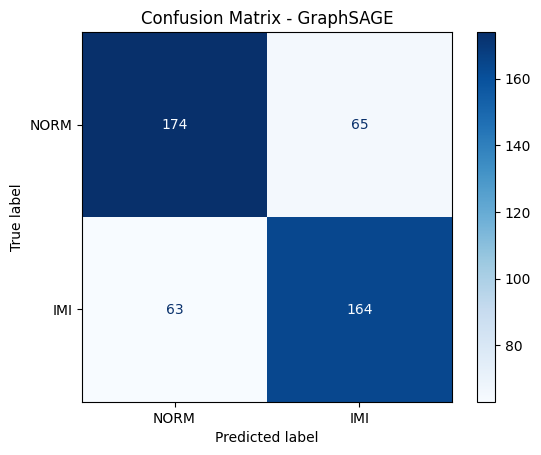

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Evaluate the model again to get predictions
model.load_state_dict(torch.load("best_graphsage_model.pth"))
model.eval()
ys, preds = [], []
with torch.no_grad():
    for batch in test_loader:
        out = model(batch.x, batch.edge_index, batch.batch)
        pred = out.argmax(dim=1)
        ys.append(batch.y.cpu())
        preds.append(pred.cpu())

ys = torch.cat(ys).numpy()
preds = torch.cat(preds).numpy()

# Compute and display the confusion matrix
cm = confusion_matrix(ys, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NORM", "IMI"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - GraphSAGE")
plt.show()


In [14]:
train_losses = []
val_accuracies = []

for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch()
    val_acc, _ = evaluate(val_loader)

    train_losses.append(train_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch:02d}, Train Loss: {train_loss:.4f}, Val Acc: {val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_gin_model.pth")
        print("Model saved.")


Training: 100%|██████████| 59/59 [00:04<00:00, 14.17it/s]


Epoch 01, Train Loss: 10.8111, Val Acc: 0.6609


Training: 100%|██████████| 59/59 [00:04<00:00, 14.39it/s]


Epoch 02, Train Loss: 9.1217, Val Acc: 0.5107


Training: 100%|██████████| 59/59 [00:04<00:00, 14.30it/s]


...

Epoch 28, Train Loss: 6.6855, Val Acc: 0.6567


Training: 100%|██████████| 59/59 [00:04<00:00, 14.42it/s]


Epoch 29, Train Loss: 5.9805, Val Acc: 0.5064


Training: 100%|██████████| 59/59 [00:04<00:00, 14.48it/s]


Epoch 30, Train Loss: 4.5213, Val Acc: 0.6330


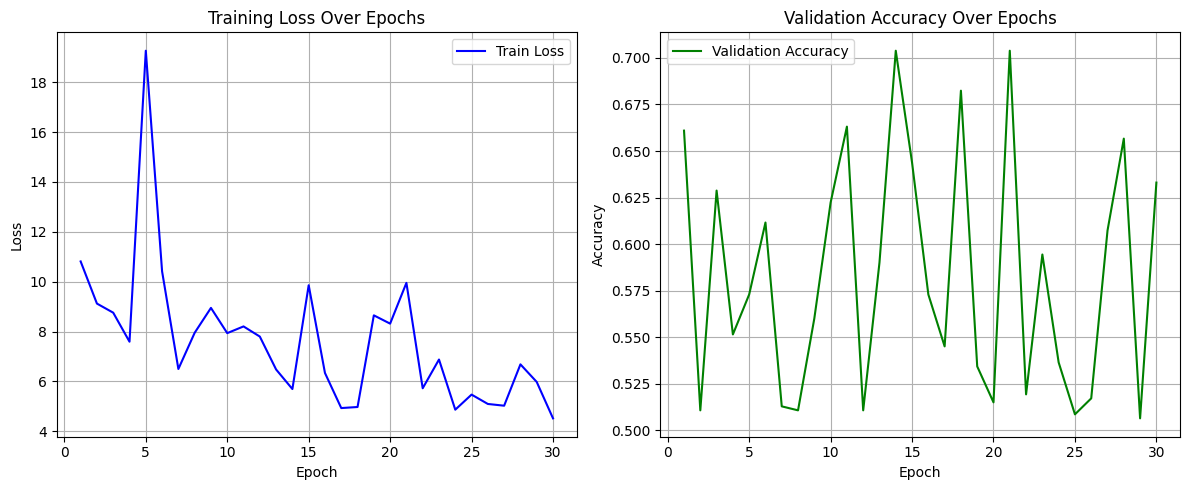

In [15]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Plot Training Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.grid(True)
plt.legend()

# Plot Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Over Epochs')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
